In [1]:
# Importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import csv
import sqlalchemy as sqla


# Loading Data into SQLite

In [2]:
# Loading CSVs into dataframes to import to SQLite db
df_sb = pd.read_csv('final_super_bowl.csv')
df_nfl_draft = pd.read_csv('final_nfl_draft.csv')
df_state_gdp = pd.read_csv('final_state_gdp.csv')

# Creating SQLite database
conn = sqlite3.connect('finalmilestone.db')
cursor = conn.cursor()

# Creating the tables that csv data will be imported into
sb_table = '''CREATE TABLE IF NOT EXISTS data_sb(
                sb_winner VARCHAR(40) NOT NULL,
                score INTEGER NOT NULL,
                sb_team VARCHAR(40) NOT NULL,
                sb_team_city VARCHAR(40) NOT NULL,
                year INTEGER NOT NULL,
                state_code VARCHAR(40) NOT NULL,
                team_code VARCHAR(40) NOT NULL,
                state_region VARCHAR(40) NOT NULL);
                '''

nfl_draft_table = '''CREATE TABLE IF NOT EXISTS data_nfl_draft(
                        player_draftyear VARCHAR(40) NOT NULL,
                        player_id VARCHAR(40) NOT NULL,
                        year INTEGER NOT NULL,
                        draft_round INTEGER NOT NULL,
                        pick INTEGER NOT NULL,
                        draft_team VARCHAR(40) NOT NULL,
                        player_name VARCHAR(40) NOT NULL,
                        made_hall_of_fame VARCHAR(40) NOT NULL,
                        position_sub VARCHAR(40) NOT NULL,
                        position_standard VARCHAR(40) NOT NULL,
                        age INTEGER NOT NULL,
                        all_pros_made INTEGER NOT NULL,
                        pro_bowls_made INTEGER NOT NULL,
                        g INTEGER NOT NULL,
                        cmp INTEGER NOT NULL,
                        pass_att INTEGER NOT NULL,
                        pass_yds INTEGER NOT NULL,
                        pass_td INTEGER NOT NULL,
                        pass_int INTEGER NOT NULL,
                        rush_att INTEGER NOT NULL,
                        rush_yds INTEGER NOT NULL,
                        rush_tds INTEGER NOT NULL,
                        rec INTEGER NOT NULL,
                        rec_yds INTEGER NOT NULL,
                        rec_tds INTEGER NOT NULL,
                        tackles INTEGER NOT NULL,
                        interceptions INTEGER NOT NULL,
                        sacks INTEGER NOT NULL,
                        college_univ VARCHAR(40) NOT NULL,
                        state_code VARCHAR(40) NOT NULL);
                        '''

state_gdp_table = '''CREATE TABLE IF NOT EXISTS data_state_gdp(
                        StateName VARCHAR(40) NOT NULL,
                        state_code VARCHAR(40) NOT NULL,
                        state_region VARCHAR(40) NOT NULL,
                        nfl_presence VARCHAR(40) NOT NULL,
                        '1998' INTEGER NOT NULL,
                        '1999' INTEGER NOT NULL,
                        '2000' INTEGER NOT NULL,
                        '2001' INTEGER NOT NULL,
                        '2002' INTEGER NOT NULL,
                        '2003' INTEGER NOT NULL,
                        '2004' INTEGER NOT NULL,
                        '2005' INTEGER NOT NULL,
                        '2006' INTEGER NOT NULL,
                        '2007' INTEGER NOT NULL,
                        '2008' INTEGER NOT NULL,
                        '2009' INTEGER NOT NULL,
                        '2010' INTEGER NOT NULL,
                        '2011' INTEGER NOT NULL,
                        '2012' INTEGER NOT NULL,
                        '2013' INTEGER NOT NULL,
                        '2014' INTEGER NOT NULL,
                        '2015' INTEGER NOT NULL);
                        '''

# Creating tables into the database
cursor.execute(sb_table)
cursor.execute(nfl_draft_table)
cursor.execute(state_gdp_table)

# insert the data from the DataFrame into the SQLite table
df_sb.to_sql('data_sb', conn, if_exists = 'replace', index = False)
df_nfl_draft.to_sql('data_nfl_draft', conn, if_exists = 'replace', index = False)
df_state_gdp.to_sql('data_state_gdp', conn, if_exists = 'replace', index = False)

51

# Merging Dataframes

In [3]:
# Merging first data together: state gdp data with nfl draft data
state_gdp_draft = df_state_gdp.merge(df_nfl_draft, on = 'state_code', how = 'left')

# Merging all datasets together to satisfy requirement
final_dataset = state_gdp_draft.merge(df_sb, on = 'state_code', how = 'left')

# Visualization #1

**Bar plot**

Text(0.5, 1.0, 'Number of Players Drafted by State 1998-2015')

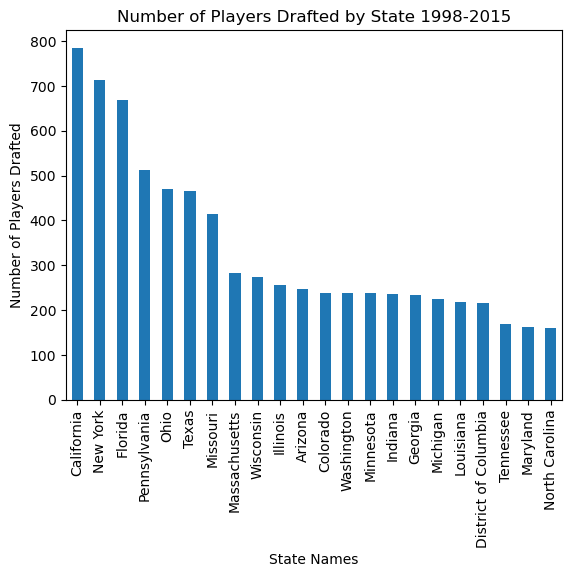

In [100]:
# Creating dataframe for visualization #1
vis1 = final_dataset[['StateName', 'nfl_presence', 'player_name']]

# Filtering for only NFL presence to compare number of draftees by state
# If state does not have an NFL team, then no draftees to report
vis1 = vis1.query("nfl_presence == 'Y'")

# Finding unique counts of players drafted grouping by StateName to show how many players were drafted by state
vis1 = vis1.groupby('StateName')['player_name'].nunique()

# Sorting values
vis1 = vis1.sort_values(ascending = False)

# Create bar plot
vis1.plot.bar()

# Adding x label
plt.xlabel("State Names")

# Adding y label
plt.ylabel("Number of Players Drafted")

# Adding title
plt.title("Number of Players Drafted by State 1998-2015")

# Visualization #2

**Line Plot**

Text(0.5, 1.0, 'Pennsylvania (Go Eagles) GDP 1998-2015')

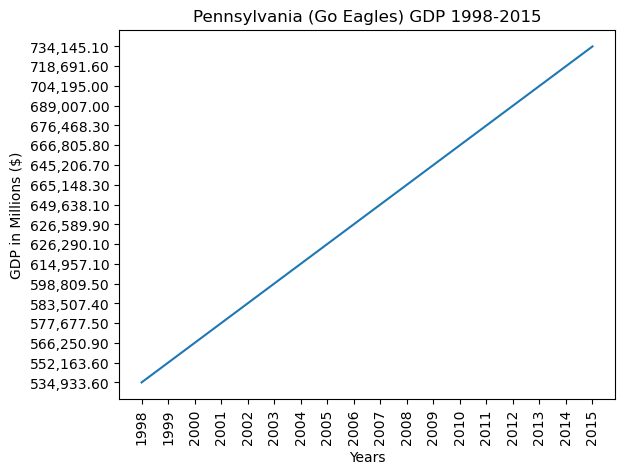

In [91]:
# Creating dataframe for visualization #2
vis2 = final_dataset[['draft_team', '1998', '1999', '2000',\
                     '2001', '2002', '2003', '2004', '2005', '2006', '2007',\
                     '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']]

# Filtering where draft_team = PHI as this is my favorite NFL team
# Looking at their GDP through the years
vis2 = vis2.query("draft_team == 'PHI'")

# Removing duplicates that were created from joining data
vis2 = vis2.drop_duplicates()

# Transpose dataframe to make it easier to plot
vis2 = vis2.transpose()

# Convert first row to column name
vis2.columns = vis2.iloc[0]

# Remove first row as it has been converted to column name
vis2 = vis2.iloc[1:]

# Plot as line graph
plt.plot(vis2['PHI'])

# Rotate the xticks to make it easier to read
plt.xticks(rotation = 90)

# Adding x label
plt.xlabel("Years")

# Adding y label
plt.ylabel("GDP in Millions ($)")

# Adding title
plt.title("Pennsylvania (Go Eagles) GDP 1998-2015")

# Visualization #3

**Bar Plot**

Text(0.5, 1.0, 'Number of University Players by Region 1998-2015')

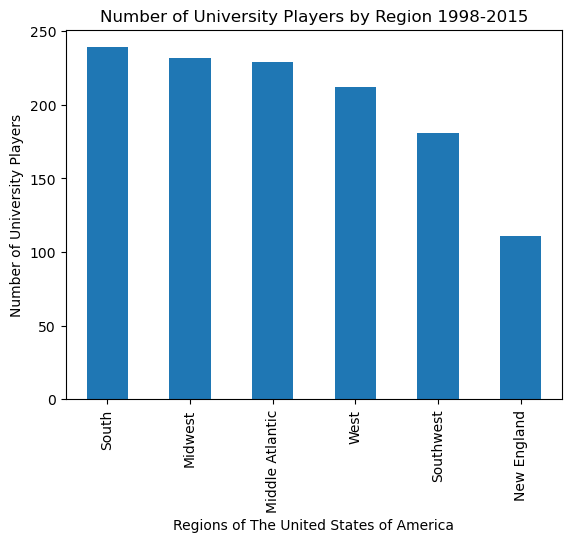

In [59]:
# Creating variable state_region_x, nfl_presence, and college_univ 
vis3 = final_dataset[['state_region_x', 'nfl_presence', 'college_univ']]

# Filtering for only NFL presence to compare number of nfl players by region
vis3 = vis3.query("nfl_presence == 'Y'")

# Finding unique counts of players drafted grouping by state_region_x to show how many players went to University
vis3 = vis3.groupby('state_region_x')['college_univ'].nunique()

# Sorting values
vis3 = vis3.sort_values(ascending = False)

# Create bar plot
vis3.plot.bar()

# Adding x label
plt.xlabel("Regions of The United States of America")

# Adding y label
plt.ylabel("Number of University Players")

# Adding title
plt.title("Number of University Players by Region 1998-2015")

# Visualization #4

**Bar Plot**

Text(0.5, 1.0, 'Number of Rounds Drafted by NFL Team 1998-2015')

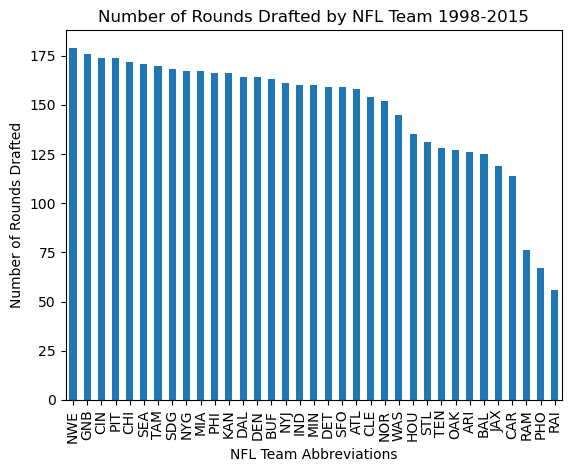

In [86]:
# Creating dataframe for visualization #4
vis4 = final_dataset[['draft_team', 'pick']]

# Grouping by draft_team and finding how many picks teams have had throughout the years
vis4 = vis4.groupby('draft_team')['pick'].nunique()

# Sorting values
vis4 = vis4.sort_values(ascending = False)

# Create bar plot
vis4.plot.bar()

# Adding x label
plt.xlabel("NFL Team Abbreviations")

# Adding y label
plt.ylabel("Number of Rounds Drafted")

# Adding title
plt.title("Number of Rounds Drafted by NFL Team 1998-2015")

# Visualization #5

**Bar Plot**

Text(0.5, 1.0, 'Number of Unique Age Occurences Drafted by Age 1998-2015')

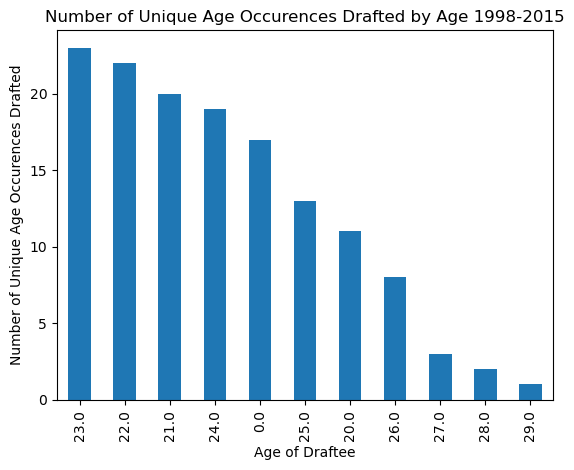

In [100]:
# Creating dataframe for visualization #5
vis5 = final_dataset[['age', 'position_sub', 'nfl_presence']]

# Filtering for only nfl_presence for positions drafted
vis5 = vis5.query("nfl_presence == 'Y'")

# Grouping by age and finding counts of position_sub to show us unique ages drafted throughout the years
vis5 = vis5.groupby('age')['position_sub'].nunique()

# Sorting values
vis5 = vis5.sort_values(ascending = False)

# Create bar plot
vis5.plot.bar()

# Adding x label
plt.xlabel("Age of Draftee")

# Adding y label
plt.ylabel("Number of Unique Age Occurences Drafted")

# Adding title
plt.title("Number of Unique Age Occurences Drafted by Age 1998-2015")

# Questions

**Changes that were made**\
Since the changes made to the data were covered in prior milestones, the changes notated here will reflect changes done within this final milestone. After merging the data together, a lot of duplicate rows were created which represented the different draft years/super bowl represenations when joining back to the state GDP. These duplicates are valid as they represent the multiple draft rounds per year for the state, so when filtering this needs to be kept in mind to ensure valid duplicates are represented.
\
**Legal/regulatory guidelines**\
No, no legal/regulatory guidelines to follow for this exercise. This was determined by initially creating the 3 datasets in prior milestones and no legal/regulatory guidelines were uncovered then as data is for public use, or created by the public for the public, or there were no API keys required and no guidelines to follow for the API calls.
\
**Risks from transformation**\
There were a lot of transformations done with the data from the prior milestones to this one. There are risks associated with doing transformations as this could lead to issues when joining the data at the end. These issues could be when transforming data could change the data to different types, so when joining this could cause issues of different types being attempted for joins. 
\
**Assumptions**\
For this milestone, I'm assuming all the data has been correctlty cleaned and joined to allow for proper comparison of data for the analysis.
\
**Sourced/verified**\
The sources were verified from the milestones they were ingested. When using the data from the final dataframe any validations were done using Google to verify the data. 
\
**Ethical data collection**\
All data was collected from other sources. These sources confirmed they were collecting the data using ethical means, which would be from public data provided by NFL or from public data provided by government for the GDP of states. 
\
**Ethical mitigation**\
Going forward, to mitigate any ethical issues one would want to validate the data coming from every source is accurate, then validate that the data transformations are also accurate to represent what analysis you are trying to display.
